# Эксперимент по оцениванию качества генерации текстового контента пятью большими языковыми моделями при ограниченных вычислительных ресурсах (этап сбора данных)

Данный Jupyter-блокнот предназначен для формирования табличного ряда наблюдений, используемого при сравнительном анализе пяти больших языковых моделей (*Gemma 4 26B*, *Qwen2.5-Coder-32B*, *YandexGPT 3 Lite 8B*, *Phi-4*, *DeepSeek-R1-Distill-Qwen-32B*) при локальном инференсе средствами **vLLM** на одном графическом процессоре **NVIDIA RTX 3090** (24 ГБ VRAM). Постановка эксперимента, условия квантования, корпус запросов, протокол сбора данных, **оценка** ответов тремя LLM-арбитрами и интерпретация результатов приведены в **[analysis.md](analysis.md)**.

**Ход исследования.** Для каждой из перечисленных конфигураций последовательно выполняется полный корпус русскоязычных запросов через OpenAI-совместимый интерфейс (`/v1/chat/completions`); фиксируются задержка генерации, скорость по данным API (tok/s), число токенов ответа и телеметрия GPU на интервале запроса.

**Схема выполнения.** Клиент Jupyter инициирует на удалённом узле с GPU команды по **SSH** (библиотека Paramiko, `docker compose up` / `stop` для выбранного сервиса); готовность сервиса vLLM проверяется по **HTTP** (`/health`). На узле одновременно допускается не более одного контейнера модели (ограничение compose и защита от конкуренции за видеопамять). Перед переходом к следующей модели выполняется остановка всего compose-проекта.

**Параметры подключения** по умолчанию заданы плейсхолдерами; при развёртывании задаются переменными окружения `BENCHMARK_*` и `OPENAI_API_KEY` (ячейка кода в разделе конфигурации ниже).

**Рекомендуемый порядок выполнения:** ячейки сверху вниз: зависимости — конфигурация — корпус — вспомогательные процедуры — основной цикл — сохранение — визуализация — заключение (markdown).


## Зависимости и подключаемые модули

Подключаются программные библиотеки, необходимые для воспроизведения протокола сбора данных: выполнение команд на удалённом узле по SSH (Paramiko), клиент OpenAI-совместимого API для обращения к vLLM (`openai`), обработка табличных данных (`pandas`), индикация хода вычислений (`tqdm`), построение графиков (`matplotlib`). Дополнительно используются модули стандартной библиотеки Python (измерение времени, потоковая синхронизация, работа со строками, HTTP-запросы для проверки доступности сервиса).


In [1]:
# %pip install -q paramiko openai pandas tqdm matplotlib

# Клиент SSH (управление docker compose на сервере).
import paramiko
# OpenAI-совместимый клиент для HTTP API vLLM (/v1/chat/completions).
from openai import OpenAI
import pandas as pd
import time
import threading
import datetime
import re
import json
import urllib.request
import urllib.error

from tqdm.notebook import tqdm
from IPython.display import display


## Параметры конфигурации

Задаются реквизиты подключения к вычислительному узлу с GPU (хост и порт SSH, каталог проекта с `docker-compose.yaml`), очерёдность **пяти** сервисов vLLM: для каждого — имя сервиса в `docker compose`, внешний порт доступа к API и строка идентификатора модели для запроса. Задаются также гиперпараметры генерации (`max_tokens`, температура), период опроса `nvidia-smi` и имя выходного CSV. Соответствие протоколу сбора данных (таблица параметров эксперимента) — §3.2 в [analysis.md](analysis.md).


In [ ]:
# Параметры сервера и путей к compose-проекту с vLLM.
import os

SERVER_HOST = os.environ.get("BENCHMARK_SSH_HOST", "<YOUR_GPU_SERVER_HOST>")
SERVER_USER = os.environ.get("BENCHMARK_SSH_USER", "<YOUR_SSH_USER>")
SERVER_PASS = os.environ.get("BENCHMARK_SSH_PASSWORD", "<YOUR_SSH_PASSWORD>")
SERVER_PORT = int(os.environ.get("BENCHMARK_SSH_PORT", "22"))

# На сервере: каталог с docker-compose.yaml и подкаталогом vllm-guard из rtx3090_five_models_vllm/
COMPOSE_DIR = os.environ.get(
    "BENCHMARK_COMPOSE_DIR",
    "/home/<YOUR_LINUX_USER>/rtx3090_five_models_vllm",
)

# Чистый локальный vLLM обычно не проверяет ключ; через прокси задайте реальный ключ в OPENAI_API_KEY.
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "<local-vllm-no-key-required>")

# Очерёдность опроса моделей: имя сервиса в docker-compose, внешний порт, имя модели в API.
MODELS = [
    {"service": "qwen3-coder",           "port": 18101, "model_name": "qwen3-coder"},
    {"service": "gemma4-26b",            "port": 18102, "model_name": "gemma-4-26b"},
    {"service": "yandexgpt-lite-8b",     "port": 18103, "model_name": "yandexgpt-5-lite-8b"},
    {"service": "phi-4",                 "port": 18104, "model_name": "phi-4"},
    {"service": "deepseek-r1-32b-awq",   "port": 18105, "model_name": "deepseek-r1-32b"},
]

# Генерация: лимит новых токенов и «почти детерминированный» режим.
MAX_TOKENS = 1024
TEMPERATURE = 0.1

# Ожидание подъёма vLLM по HTTP /health.
HEALTH_TIMEOUT = 300
HEALTH_INTERVAL = 5

# Как часто опрашивать GPU по SSH во время одного запроса к модели.
GPU_POLL_INTERVAL = 1.0

# Итоговая таблица на диске (каталог = текущая рабочая папка Jupyter).
OUTPUT_CSV = "benchmark_results.csv"


## Корпус запросов

Структура корпуса согласована с §3.1 [analysis.md](analysis.md) и с файлом **`questions.txt`** (текстовый экспорт из настоящего блокнота). Корпус содержит **100** заданий (`Q01`–`Q100`), **десять** тематических категорий по 10 запросов в каждой; описание категорий см. в [analysis.md](analysis.md). Поле `category` задаёт стратификацию при последующей агрегации **оценок** LLM-арбитрами.


In [3]:
QUESTIONS = [
    {"id": "Q01", "category": "math_logic", "text": "Докажи или опровергни: сумма любых двух нечётных чисел всегда чётна. Используй алгебраическое доказательство."},
    {"id": "Q02", "category": "math_logic", "text": "Поезд едет из A в B со скоростью 80 км/ч, обратно — 120 км/ч. Чему равна средняя скорость за всю поездку? Почему ответ не 100 км/ч?"},
    {"id": "Q03", "category": "math_logic", "text": "В комнате 23 человека. Какова вероятность, что хотя бы у двух совпадают дни рождения? Объясни парадокс и дай приближённый численный ответ."},
    {"id": "Q04", "category": "math_logic", "text": "Три коробки с надписями «яблоки», «апельсины», «яблоки и апельсины». Все три надписи неправильные. Можно достать один фрукт из одной коробки. Как определить содержимое всех трёх?"},
    {"id": "Q05", "category": "math_logic", "text": "Что такое число e (≈2.718)? Объясни его смысл через задачу о непрерывном начислении процентов — без производных."},
    {"id": "Q06", "category": "math_logic", "text": "Монета подброшена 10 раз, каждый раз выпадал орёл. Какова вероятность орла на 11-м броске? Почему интуиция здесь систематически ошибается?"},
    {"id": "Q07", "category": "math_logic", "text": "Докажи, что √2 иррационально. Используй доказательство от противного."},
    {"id": "Q08", "category": "math_logic", "text": "100 заключённых, каждому присвоен номер 1–100. В комнате 100 ящиков с номерами внутри. Каждый может открыть не более 50 ящиков. Какова оптимальная стратегия? (задача о заключённых и ящиках)"},
    {"id": "Q09", "category": "math_logic", "text": "Докажи методом математической индукции, что сумма первых n натуральных чисел равна n(n+1)/2."},
    {"id": "Q10", "category": "math_logic", "text": "В чём разница между необходимым и достаточным условием? Приведи пример из математики и из повседневной жизни."},
    {"id": "Q11", "category": "applied_science", "text": "Объясни разницу между L1 и L2-регуляризацией: интуитивно и формально. Когда предпочесть L1?"},
    {"id": "Q12", "category": "applied_science", "text": "Что такое vanishing gradient? Почему он возникает и как с ним борются в современных архитектурах?"},
    {"id": "Q13", "category": "applied_science", "text": "Почему батч-нормализация работает хуже при batch_size=1? Что используют вместо неё?"},
    {"id": "Q14", "category": "applied_science", "text": "В чём принципиальная разница между BERT и GPT с точки зрения архитектуры и задач, для которых они оптимальны?"},
    {"id": "Q15", "category": "applied_science", "text": "Когда стоит использовать cosine similarity вместо dot product для сравнения эмбеддингов?"},
    {"id": "Q16", "category": "applied_science", "text": "Объясни CAP-теорему на примере реальной системы. Какой компромисс выбирают PostgreSQL и Cassandra?"},
    {"id": "Q17", "category": "applied_science", "text": "Что такое информационная энтропия и как она связана с функцией потерь cross-entropy в задачах классификации?"},
    {"id": "Q18", "category": "applied_science", "text": "Почему квантизация INT8 теряет меньше качества, чем INT4? Что происходит с распределением весов при агрессивной квантизации?"},
    {"id": "Q19", "category": "applied_science", "text": "Объясни механизм attention без формул — через аналогию из реальной жизни. Что такое self-attention и почему он мощнее RNN?"},
    {"id": "Q20", "category": "applied_science", "text": "В чём разница между precision@k и NDCG как метриками ранжирования? Когда каждая из них важнее?"},
    {"id": "Q21", "category": "coding", "text": "Напиши функцию на Python: принимает список целых чисел, возвращает все пары с суммой 0. Сложность O(n). Приведи пример вызова."},
    {"id": "Q22", "category": "coding", "text": "Объясни разницу между asyncio.gather и asyncio.wait в Python. Когда использовать каждый? Короткий пример."},
    {"id": "Q23", "category": "coding", "text": "В чём опасность этого кода и как исправить?\ndef append_to(element, to=[]):\n    to.append(element)\n    return to"},
    {"id": "Q24", "category": "coding", "text": "Напиши SQL-запрос: таблица orders(id, user_id, amount, created_at). Топ-3 пользователя по сумме заказов за последние 30 дней, исключи тех, у кого менее 2 заказов."},
    {"id": "Q25", "category": "coding", "text": "Что такое утечка памяти в Python? Может ли она возникнуть несмотря на сборщик мусора? Приведи конкретный пример кода."},
    {"id": "Q26", "category": "coding", "text": "Найди все баги и исправь:\ndef fibonacci(n):\n    if n == 0: return 1\n    if n == 1: return 1\n    return fibonacci(n-1) + fibonacci(n-2)\nprint(fibonacci(-1))"},
    {"id": "Q27", "category": "coding", "text": "Объясни разницу между shallow copy и deep copy в Python. Когда каждая ведёт себя неожиданно?"},
    {"id": "Q28", "category": "coding", "text": "Напиши декоратор @retry(times=3, delay=1): повторяет вызов функции при исключении до times раз с задержкой delay секунд."},
    {"id": "Q29", "category": "coding", "text": "Что такое индекс в БД? Разница между B-tree и Hash индексами. Когда каждый тип предпочтителен?"},
    {"id": "Q30", "category": "coding", "text": "Датафрейм pandas на 10 млн строк. df[df['col'] > 0] работает медленно. Назови три способа ускорить фильтрацию."},
    {"id": "Q31", "category": "linux_cli", "text": "Найди все процессы, использующие больше 1 ГБ памяти, отсортируй по убыванию. Приведи команду."},
    {"id": "Q32", "category": "linux_cli", "text": "Как узнать, какой процесс слушает порт 8000? Приведи два способа."},
    {"id": "Q33", "category": "linux_cli", "text": "Удали все файлы старше 7 дней в /tmp, не трогая поддиректории. Приведи команду find с нужными флагами."},
    {"id": "Q34", "category": "linux_cli", "text": "Найди 10 самых больших файлов начиная с /. Как исключить псевдофайловые системы /proc и /sys?"},
    {"id": "Q35", "category": "linux_cli", "text": "Как запустить команду в фоне так, чтобы она не завершилась после закрытия SSH-сессии? Разница между nohup, screen и tmux."},
    {"id": "Q36", "category": "linux_cli", "text": "Смотришь логи в реальном времени, хочешь видеть только строки с ERROR. Напиши команду с tail и grep."},
    {"id": "Q37", "category": "linux_cli", "text": "Как скопировать директорию с удалённого сервера на локальную машину по SSH без ввода пароля? Объясни настройку ключей."},
    {"id": "Q38", "category": "linux_cli", "text": "Диск заполнен на 100%, сервер не отвечает. Назови последовательность команд: что занимает место и в какой директории."},
    {"id": "Q39", "category": "linux_cli", "text": "Что такое файловые дескрипторы? Как посмотреть открытые дескрипторы конкретного процесса? Как увеличить лимит?"},
    {"id": "Q40", "category": "linux_cli", "text": "Как ограничить CPU и память при запуске команды? Покажи пример через systemd-run или ulimit."},
    {"id": "Q41", "category": "docker_devops", "text": "Docker-контейнер запускается и сразу падает. Как диагностировать? Назови последовательность команд docker для выяснения причины."},
    {"id": "Q42", "category": "docker_devops", "text": "Как посмотреть логи docker-контейнера только за последние 30 минут с временными метками? Приведи точную команду."},
    {"id": "Q43", "category": "docker_devops", "text": "Как войти внутрь работающего docker-контейнера и проверить переменные окружения, не прерывая его работу?"},
    {"id": "Q44", "category": "docker_devops", "text": "Как одной командой очистить docker-систему от всех остановленных контейнеров, неиспользуемых образов, томов и сетей?"},
    {"id": "Q45", "category": "docker_devops", "text": "Docker-контейнер с vLLM не видит GPU. Перечисли всё, что нужно проверить, в порядке приоритета."},
    {"id": "Q46", "category": "docker_devops", "text": "Как передать конкретный GPU (второй из трёх) в docker-контейнер через docker-compose, не используя NVIDIA_VISIBLE_DEVICES=all?"},
    {"id": "Q47", "category": "docker_devops", "text": "Docker-контейнер завершился с exit code 137. Что это означает? Как отличить OOM Killer от ручной остановки через docker stop?"},
    {"id": "Q48", "category": "docker_devops", "text": "Как пересобрать образ и перезапустить один сервис в docker-compose без остановки остальных сервисов?"},
    {"id": "Q49", "category": "docker_devops", "text": "vLLM в docker-контейнере падает с CUDA out of memory во время захвата CUDA-графов при старте. Какие параметры менять и в каком порядке?"},
    {"id": "Q50", "category": "docker_devops", "text": "Как смонтировать директорию хоста в docker-контейнер только для чтения? Чем bind mount отличается от named volume?"},
    {"id": "Q51", "category": "reasoning", "text": "Фирма продаёт зонтики и солнечные очки. Директор говорит: «Нам не важно, какая погода — в любом случае мы в плюсе». Найди изъян в этом рассуждении."},
    {"id": "Q52", "category": "reasoning", "text": "«Корреляция не означает причинно-следственную связь». Приведи три реальных примера, где корреляция есть, а причинности нет."},
    {"id": "Q53", "category": "reasoning", "text": "Убеди скептика, что Земля круглая, используя только наблюдения, доступные без интернета и современных технологий."},
    {"id": "Q54", "category": "reasoning", "text": "Парадокс Ферми: если внеземные цивилизации должны существовать, почему мы их не наблюдаем? Три наиболее убедительных объяснения."},
    {"id": "Q55", "category": "reasoning", "text": "Ты узнал, что вчерашнее решение основано на ложной предпосылке, но оно уже принесло хорошие результаты. Менять его или нет? Разбери с разных точек зрения."},
    {"id": "Q56", "category": "reasoning", "text": "Выбор: 100% шанс получить 50 рублей или 50% шанс получить 120 рублей. Что выбрать? Изменится ли ответ при 50 000 и 120 000?"},
    {"id": "Q57", "category": "reasoning", "text": "Почему запрет чего-либо часто приводит к обратному эффекту? Как называется этот феномен? Приведи исторические примеры."},
    {"id": "Q58", "category": "reasoning", "text": "Компания уволила 20% сотрудников, производительность выросла на 15%. Назови четыре альтернативных объяснения этой статистики."},
    {"id": "Q59", "category": "reasoning", "text": "В чём принципиальная разница между объяснением и оправданием? Пример, где одно высказывание может быть и тем, и другим."},
    {"id": "Q60", "category": "reasoning", "text": "Сформулируй три вопроса, которые нужно задать любой статистике, прежде чем делать из неё выводы."},
    {"id": "Q61", "category": "geospatial", "text": "Если выйти из Лондона и идти строго на юг, какая суша встретится первой? Почему большинство людей отвечают неправильно?"},
    {"id": "Q62", "category": "geospatial", "text": "Назови все страны, через которые проходит экватор. Сколько их?"},
    {"id": "Q63", "category": "geospatial", "text": "Какой континент является одновременно самым сухим, холодным и ветреным? Объясни почему."},
    {"id": "Q64", "category": "geospatial", "text": "Если в Москве 12:00 понедельника, какое время в Токио, Нью-Йорке и на линии перемены дат? Объясни логику часовых поясов."},
    {"id": "Q65", "category": "geospatial", "text": "Назови три города, которые находятся южнее, чем принято думать, и три города, которые севернее, чем кажется."},
    {"id": "Q66", "category": "geospatial", "text": "Почему Австралия — одновременно континент, страна и остров? Чем континент отличается от острова с точки зрения геологии?"},
    {"id": "Q67", "category": "geospatial", "text": "Нил и Амазонка: какая длиннее, а какая полноводнее? Почему ответ зависит от методологии измерения?"},
    {"id": "Q68", "category": "geospatial", "text": "Почему кратчайший путь между двумя точками на глобусе выглядит кривой линией на плоской карте Меркатора?"},
    {"id": "Q69", "category": "geospatial", "text": "Существуют ли страны, не имеющие выхода к морю и граничащие только с такими же странами без выхода к морю? Если да — назови их."},
    {"id": "Q70", "category": "geospatial", "text": "Как изменилась карта Европы с 1990 по 2000 год? Назови все государства, появившиеся и исчезнувшие за это десятилетие."},
    {"id": "Q71", "category": "humanities", "text": "Почему распад СССР в 1991 году произошёл именно так? Три ключевых фактора: экономический, политический, идеологический."},
    {"id": "Q72", "category": "humanities", "text": "В чём принципиальное различие между Реформацией и Контрреформацией? Как они изменили политическую карту Европы к XVII веку?"},
    {"id": "Q73", "category": "humanities", "text": "Как биржевой крах 1929 года превратился в глобальный кризис? Объясни механизм распространения Великой депрессии."},
    {"id": "Q74", "category": "humanities", "text": "Что такое «ловушка Фукидида» и почему этот термин актуален сегодня? Приведи примеры подтверждения и опровержения из истории."},
    {"id": "Q75", "category": "humanities", "text": "Чем утилитаризм Бентама отличается от категорического императива Канта? Как каждая система решает дилемму «вагонетки»?"},
    {"id": "Q76", "category": "humanities", "text": "Объясни феномен «банальности зла» по Ханне Арендт. Какие современные примеры иллюстрируют этот концепт?"},
    {"id": "Q77", "category": "humanities", "text": "Что такое «окно Овертона» и как оно работает? Три примера его сдвига в разных обществах за последние 50 лет."},
    {"id": "Q78", "category": "humanities", "text": "В чём разница между федерацией, конфедерацией и унитарным государством? По одному примеру каждого типа с обоснованием выбора формы."},
    {"id": "Q79", "category": "humanities", "text": "Почему промышленная революция началась в Англии, а не во Франции или Германии? Не менее четырёх факторов."},
    {"id": "Q80", "category": "humanities", "text": "Что такое «демографический переход»? В какой фазе находятся Россия, Китай и Нигерия сегодня? Каковы последствия для каждой?"},
    {"id": "Q81", "category": "russian_culture", "text": "Объясни происхождение и современный смысл поговорки «Незваный гость хуже татарина»."},
    {"id": "Q82", "category": "russian_culture", "text": "В чём разница между пословицей и поговоркой? Приведи по три примера каждой и объясни различие на них."},
    {"id": "Q83", "category": "russian_culture", "text": "Объясни смысл «Тише едешь — дальше будешь». Ситуация, где совет работает, и ситуация, где он вреден."},
    {"id": "Q84", "category": "russian_culture", "text": "Назови пять русских пословиц о труде и лени. Объясни каждую. Противоречат ли они друг другу?"},
    {"id": "Q85", "category": "russian_culture", "text": "«Что русскому здорово, то немцу смерть»: каков культурный смысл? Есть ли аналоги в других языках?"},
    {"id": "Q86", "category": "russian_culture", "text": "Кто такой Иван-дурак в русских сказках? Почему именно он, а не умные братья, достигает успеха? Каков архетип этого образа?"},
    {"id": "Q87", "category": "russian_culture", "text": "Объясни феномен русского «авось». Как эта черта проявляется в истории, литературе и повседневной жизни?"},
    {"id": "Q88", "category": "russian_culture", "text": "Назови ключевые произведения «Золотого века» русской литературы. Чем он отличается от «Серебряного» по тематике и духу?"},
    {"id": "Q89", "category": "russian_culture", "text": "Что такое «хтонь» в современном русском интернет-сленге? Откуда это слово и какой культурный пласт оно описывает?"},
    {"id": "Q90", "category": "russian_culture", "text": "Объясни явление «кухонных разговоров» в советскую эпоху. Какую социальную функцию они выполняли? Есть ли аналог сегодня?"},
    {"id": "Q91", "category": "russian_language", "text": "Объясни разницу между «одеть» и «надеть». Два предложения, где перепутать их — грубая ошибка."},
    {"id": "Q92", "category": "russian_language", "text": "Что означает фразеологизм «положить зубы на полку»? Составь диалог, в котором он используется уместно."},
    {"id": "Q93", "category": "russian_language", "text": "Расставь знаки препинания и объясни каждый: «Казнить нельзя помиловать». В каких ситуациях эта фраза стала символом?"},
    {"id": "Q94", "category": "russian_language", "text": "Объясни разницу между паронимами «абонент / абонемент» и «командировочный / командированный». Составь предложения."},
    {"id": "Q95", "category": "russian_language", "text": "Как правильно: «Скучаю по вас» или «Скучаю по вам»? Объясни норму и её историческое изменение."},
    {"id": "Q96", "category": "russian_language", "text": "Что такое «канцелярит» по Корнею Чуковскому? Пример канцелярского текста — и перепиши его живым языком."},
    {"id": "Q97", "category": "russian_language", "text": "Объясни разницу между деепричастием и причастием. Найди ошибку и исправь: «Подходя к дому, у меня заболела голова»."},
    {"id": "Q98", "category": "russian_language", "text": "Какие иностранные слова вошли в русский язык за последние 20 лет? Десять примеров с указанием языка-источника."},
    {"id": "Q99", "category": "russian_language", "text": "Расставь ударения и объясни правило: договор, звонит, каталог, красивее, средства, шарфы, торты, банты."},
    {"id": "Q100", "category": "russian_language", "text": "Напиши эссе 100–120 слов на тему «Почему точность языка важна в технической документации». Критерии: ни одного штампа, ни одного канцеляризма."}
]

## Вспомогательные процедуры

Ниже определены процедуры протокола наблюдений на стороне клиента Jupyter:

- **ssh_exec** — потокобезопасное выполнение удалённой shell-команды по одному SSH-каналу;
- **start_model**, **stop_model**, **stop_all_compose_services** — управление жизненным циклом контейнеров через `docker compose` в каталоге проекта;
- **wait_for_model** — ожидание готовности vLLM по запросу `GET /health` к проброшенному порту узла;
- **gpu_poller** — периодический опрос температуры и загрузки GPU по SSH на длительности одного запроса к модели;
- **query_model** — один вызов `chat.completions` с фиксацией задержки и скорости по данным Usage API; из текста ответа удаляются блоки внутреннего рассуждения, если они присутствуют.


In [4]:
# Общий замок: один SSH-канал, фоновый поток nvidia-smi и основной поток не должны
# вызывать exec_command одновременно без синхронизации.
ssh_lock = threading.Lock()


def ssh_exec(client, command):
    """Выполнить одну shell-команду на удалённом хосте через Paramiko.

    Потокобезопасно: все вызовы сериализуются через `ssh_lock`, чтобы не смешивать
    потоки stdout/stderr от параллельных `exec_command` на одном клиенте.

    Args:
        client: открытый `paramiko.SSHClient`.
        command: строка команды (как в интерактивном ssh).

    Returns:
        tuple[str, str, int]: (stdout, stderr, код_выхода).
    """
    with ssh_lock:
        _stdin, stdout, stderr = client.exec_command(command, get_pty=False)
        out_b = stdout.read()
        err_b = stderr.read()
        exit_code = stdout.channel.recv_exit_status()
    return out_b.decode("utf-8", errors="replace"), err_b.decode("utf-8", errors="replace"), exit_code


def start_model(ssh_client, service_name):
    """Поднять один сервис vLLM: `docker compose up -d <service>` в `COMPOSE_DIR`.

    Raises:
        RuntimeError: если compose вернул ненулевой код выхода.
    """
    cmd = f"cd {COMPOSE_DIR} && docker compose up -d {service_name}"
    out, err, code = ssh_exec(ssh_client, cmd)
    if code != 0:
        raise RuntimeError(f"Не удалось запустить сервис {service_name}. stderr: {err.strip() or out.strip()}")


def stop_model(ssh_client, service_name):
    """Остановить сервис: `docker compose stop <service>` в каталоге проекта.

    Raises:
        RuntimeError: при ошибке docker compose.
    """
    cmd = f"cd {COMPOSE_DIR} && docker compose stop {service_name}"
    out, err, code = ssh_exec(ssh_client, cmd)
    if code != 0:
        raise RuntimeError(f"Не удалось остановить сервис {service_name}. stderr: {err.strip() or out.strip()}")


def stop_all_compose_services(ssh_client):
    """Остановить все сервисы текущего compose-проекта (`docker compose stop` без имён).

    Нужен перед запуском следующей модели: на GPU допустим только один контейнер vLLM,
    guard на сервере тоже блокирует второй, но «залипший» контейнер лучше гасить явно.

    Raises:
        RuntimeError: если команда завершилась с ошибкой.
    """
    cmd = f"cd {COMPOSE_DIR} && docker compose stop"
    out, err, code = ssh_exec(ssh_client, cmd)
    if code != 0:
        raise RuntimeError(f"docker compose stop завершился с кодом {code}. stderr: {err.strip()}")


def wait_for_model(port, timeout=HEALTH_TIMEOUT, interval=HEALTH_INTERVAL):
    """Дождаться готовности эндпоинта vLLM: периодически запрашивать GET /health.

    Args:
        port: внешний порт на SERVER_HOST, проброшенный на :8000 контейнера.
        timeout: максимальное время ожидания (секунды).
        interval: пауза между попытками (секунды).

    Raises:
        TimeoutError: если за `timeout` ни разу не получен HTTP 200.
    """
    url = f"http://{SERVER_HOST}:{port}/health"
    deadline = time.time() + timeout
    while time.time() < deadline:
        try:
            with urllib.request.urlopen(url, timeout=15) as resp:
                if resp.getcode() == 200:
                    return
        except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, OSError):
            pass
        time.sleep(interval)
    raise TimeoutError(f"Healthcheck не прошёл за {timeout} с (порт {port}, URL {url})")


def gpu_poller(ssh_client, stop_event, results_list):
    """Фоновый опрос GPU по SSH, пока не выставлен `stop_event`.

    Раз в `GPU_POLL_INTERVAL` секунд выполняется `nvidia-smi` в CSV-формате; первая строка
    вида «temp, util» добавляется в `results_list` как (temperature_c, utilization_pct).
    Остановка: главный поток выставляет `stop_event`; поток выходит из цикла.

    Args:
        ssh_client: тот же SSH-клиент, что и для docker (сервер с GPU).
        stop_event: threading.Event; после генерации ответа выставить .set().
        results_list: изменяемый список для накопления кортежей (temp, util).
    """
    cmd = "nvidia-smi --query-gpu=temperature.gpu,utilization.gpu --format=csv,noheader,nounits"
    while not stop_event.is_set():
        out, err, code = ssh_exec(ssh_client, cmd)
        if code == 0 and out.strip():
            line = out.strip().splitlines()[0]
            parts = [p.strip() for p in line.split(",")]
            if len(parts) >= 2:
                try:
                    temp = int(float(parts[0]))
                    util = int(float(parts[1]))
                    results_list.append((temp, util))
                except ValueError:
                    pass
        if stop_event.wait(GPU_POLL_INTERVAL):
            break


def query_model(base_url, model_name, question_text):
    """Один запрос чата к vLLM через OpenAI-совместимый API.

    Измеряет задержку, читает `completion_tokens`, убирает из текста блоки
    `<think>...</think>` (если модель их вставляет).
    Любая сеть/API ошибка не бросается наружу: возвращается answer с префиксом «ERROR:».

    Args:
        base_url: например `http://192.168.54.214:18101/v1`.
        model_name: значение `served-model-name` из compose.
        question_text: текст пользовательского сообщения.

    Returns:
        dict с ключами: answer (str), latency_s (float), tokens (int), tok_per_sec (float).
    """
    client = OpenAI(base_url=base_url, api_key=OPENAI_API_KEY)
    t0 = time.perf_counter()
    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": question_text}],
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        t1 = time.perf_counter()
        latency_s = round(t1 - t0, 2)
        text = (resp.choices[0].message.content or "")
        text = re.sub(
            r"<think>[\s\S]*?</think>",
            "",
            text,
            flags=re.IGNORECASE,
        )
        text = text.strip()
        tokens = 0
        if resp.usage is not None and resp.usage.completion_tokens is not None:
            tokens = int(resp.usage.completion_tokens)
        tok_per_sec = round(tokens / latency_s, 1) if latency_s > 0 else 0.0
        return {
            "answer": text,
            "latency_s": latency_s,
            "tokens": tokens,
            "tok_per_sec": tok_per_sec,
        }
    except Exception as e:
        return {
            "answer": f"ERROR: {e!s}",
            "latency_s": 0.0,
            "tokens": 0,
            "tok_per_sec": 0.0,
        }


## Основной цикл оценки качества генерации контента

Для каждой записи списка `MODELS` выполняется: остановка всех сервисов compose-проекта; запуск целевого сервиса vLLM; ожидание успешного health-check; для каждого элемента корпуса `QUESTIONS` — запрос к API при параллельном сборе телеметрии GPU; добавление строки результата в список `rows`; остановка сервиса; пауза перед следующей моделью (снижение риска неполного освобождения ресурсов на узле).

Число HTTP-запросов равно `len(MODELS) × len(QUESTIONS)` (при пяти моделях и ста запросах — порядка **500**); длительность прогона определяется скоростью декодирования, таймаутами и свойствами сети. Сводные количественные результаты и материалы **оценки** тремя LLM-арбитрами изложены в [analysis.md](analysis.md) (разделы 4–5).


In [5]:
# Накопление строк результата: каждая строка — один (модель × вопрос).
rows = []

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(
    hostname=SERVER_HOST,
    port=SERVER_PORT,
    username=SERVER_USER,
    password=SERVER_PASS,
    allow_agent=False,
    look_for_keys=False,
)

try:
    for m in MODELS:
        service = m["service"]
        port = m["port"]
        model_name = m["model_name"]
        print(f">>> Запуск модели: {service} ({port})")

        # Гарантированно гасим предыдущий vLLM, чтобы освободить GPU.
        stop_all_compose_services(ssh)
        time.sleep(2)

        start_model(ssh, service)
        wait_for_model(port)
        print("    Модель готова. Начинаю опрос...")

        base_url = f"http://{SERVER_HOST}:{port}/v1"

        for q in tqdm(QUESTIONS, desc=f"{service}"):
            gpu_readings = []
            stop_ev = threading.Event()
            poller_thread = threading.Thread(
                target=gpu_poller,
                args=(ssh, stop_ev, gpu_readings),
                daemon=True,
            )
            poller_thread.start()

            # Пока идёт HTTP-запрос, poller собирает температуру и загрузку GPU.
            r = query_model(base_url, model_name, q["text"])

            stop_ev.set()
            poller_thread.join(timeout=5.0)

            # Для отчёта берём пиковые значения за интервал генерации.
            if gpu_readings:
                gpu_temp = max(t for t, _ in gpu_readings)
                gpu_util = max(u for _, u in gpu_readings)
            else:
                gpu_temp = None
                gpu_util = None

            ts = datetime.datetime.now(datetime.timezone.utc).isoformat()
            rows.append({
                "question_id": q["id"],
                "category": q["category"],
                "question_text": q["text"],
                "model_service": service,
                "model_name": model_name,
                "answer": r["answer"],
                "tok_per_sec": r["tok_per_sec"],
                "latency_s": r["latency_s"],
                "tokens": r["tokens"],
                "gpu_temp_c": gpu_temp,
                "gpu_util_pct": gpu_util,
                "timestamp": ts,
            })

        stop_model(ssh, service)
        print(f"    Остановлен {service}. Пауза 10 с...")
        time.sleep(10)

finally:
    ssh.close()

print("Цикл завершён.")

>>> Запуск модели: qwen3-coder (18101)
    Модель готова. Начинаю опрос...


qwen3-coder:   0%|          | 0/100 [00:00<?, ?it/s]

    Остановлен qwen3-coder. Пауза 10 с...
>>> Запуск модели: gemma4-26b (18102)
    Модель готова. Начинаю опрос...


gemma4-26b:   0%|          | 0/100 [00:00<?, ?it/s]

    Остановлен gemma4-26b. Пауза 10 с...
>>> Запуск модели: yandexgpt-lite-8b (18103)
    Модель готова. Начинаю опрос...


...

    Остановлен yandexgpt-lite-8b. Пауза 10 с...
>>> Запуск модели: phi-4 (18104)
    Модель готова. Начинаю опрос...


phi-4:   0%|          | 0/100 [00:00<?, ?it/s]

    Остановлен phi-4. Пауза 10 с...
>>> Запуск модели: deepseek-r1-32b-awq (18105)
    Модель готова. Начинаю опрос...


deepseek-r1-32b-awq:   0%|          | 0/100 [00:00<?, ?it/s]

    Остановлен deepseek-r1-32b-awq. Пауза 10 с...
Цикл завершён.


## Сохранение результатов и предпросмотр

Накопленные строки преобразуются в объект `pandas.DataFrame` с фиксированным порядком столбцов и записываются в файл **`benchmark_results.csv`** (кодировка UTF-8 с BOM для корректного открытия в Microsoft Excel). Агрегаты по моделям соответствуют по смыслу разделам об эксплуатационных метриках и телеметрии GPU в [analysis.md](analysis.md) (§4.1–4.2). Логические выводы о назначении табличного артефакта и обобщении протокола приведены в **заключительном разделе** блокнота (после визуализации).


In [6]:
# Фиксированный порядок колонок — удобно для последующего «арбитра» по CSV.
cols = [
    "question_id",
    "category",
    "question_text",
    "model_service",
    "model_name",
    "answer",
    "tok_per_sec",
    "latency_s",
    "tokens",
    "gpu_temp_c",
    "gpu_util_pct",
    "timestamp",
]

df = pd.DataFrame(rows, columns=cols)
# utf-8-sig: Excel на Windows корректно открывает кириллицу.
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Сохранено: {OUTPUT_CSV}")
print(f"Строк: {len(df)}, моделей: {df['model_service'].nunique()}, вопросов на модель: {len(QUESTIONS)}")
display(df.head(10))

summary = df.groupby("model_service")[["tok_per_sec", "gpu_temp_c", "gpu_util_pct"]].mean()
print("Средние по моделям:")
display(summary)


Сохранено: benchmark_results.csv
Строк: 500, моделей: 5, вопросов на модель: 100


,question_id,category,question_text,model_service,model_name,answer,tok_per_sec,latency_s,tokens,gpu_temp_c,gpu_util_pct,timestamp
0,Q01,math_logic,Докажи или опровергни: сумма любых двух нечётн...,qwen3-coder,qwen3-coder,Докажем утверждение:\n\n> **Сумма любых двух н...,125.6,2.23,280,52,100,2026-04-30T12:28:53.167938+00:00
1,Q02,math_logic,"Поезд едет из A в B со скоростью 80 км/ч, обра...",qwen3-coder,qwen3-coder,Чтобы найти **среднюю скорость** на протяжении...,166.3,3.29,547,54,100,2026-04-30T12:28:56.741572+00:00
2,Q03,math_logic,"В комнате 23 человека. Какова вероятность, что...",qwen3-coder,qwen3-coder,### Задача: Вероятность совпадения дней рожден...,165.7,5.02,832,56,100,2026-04-30T12:29:02.050073+00:00
3,Q04,math_logic,"Три коробки с надписями «яблоки», «апельсины»,...",qwen3-coder,qwen3-coder,Это классическая логическая задача. Давайте ра...,165.7,6.18,1024,58,100,2026-04-30T12:29:08.500471+00:00
4,Q05,math_logic,Что такое число e (≈2.718)? Объясни его смысл ...,qwen3-coder,qwen3-coder,"Представим, что у тебя есть 1 рубль, и ты хоче...",164.7,3.97,654,59,100,2026-04-30T12:29:12.790623+00:00
5,Q06,math_logic,"Монета подброшена 10 раз, каждый раз выпадал о...",qwen3-coder,qwen3-coder,"Это классическая задача, которая часто использ...",164.8,3.04,501,59,100,2026-04-30T12:29:16.125830+00:00
6,Q07,math_logic,"Докажи, что √2 иррационально. Используй доказа...",qwen3-coder,qwen3-coder,"Докажем, что $\sqrt{2}$ — иррациональное число...",165.4,3.79,627,60,100,2026-04-30T12:29:20.184254+00:00
7,Q08,math_logic,"100 заключённых, каждому присвоен номер 1–100....",qwen3-coder,qwen3-coder,"Эта задача — классический пример **стратегии ""...",163.8,5.25,860,61,100,2026-04-30T12:29:25.718046+00:00
8,Q09,math_logic,"Докажи методом математической индукции, что су...",qwen3-coder,qwen3-coder,Доказательство методом **математической индукц...,164.4,3.71,610,61,100,2026-04-30T12:29:29.869130+00:00
9,Q10,math_logic,В чём разница между необходимым и достаточным ...,qwen3-coder,qwen3-coder,Разница между **необходимым** и **достаточным*...,164.2,4.58,752,62,100,2026-04-30T12:29:34.840344+00:00


Средние по моделям:


,tok_per_sec,gpu_temp_c,gpu_util_pct
model_service,,,
deepseek-r1-32b-awq,34.289,68.04,100.00
gemma4-26b,43.038,66.10,47.76
phi-4,75.246,67.85,100.00
qwen3-coder,162.417,66.25,100.00
yandexgpt-lite-8b,44.337,66.54,100.00


## Иллюстративная визуализация

По данным таблицы `df` строятся два столбчатых графика:

1. средняя скорость генерации (**tok/s**) по идентификатору сервиса (индикатор пропускной способности декодирования при заданных настройках vLLM и квантования);
2. среднее по опросам значение температуры GPU (**°C**) — сопоставимо с описанием телеметрии в [analysis.md](analysis.md) (§4.2; см. также утилизацию GPU и флаг `--enforce-eager` для Gemma 4 26B).

Графики формируются при успешном выполнении предыдущих ячеек и непустом объекте `df`.


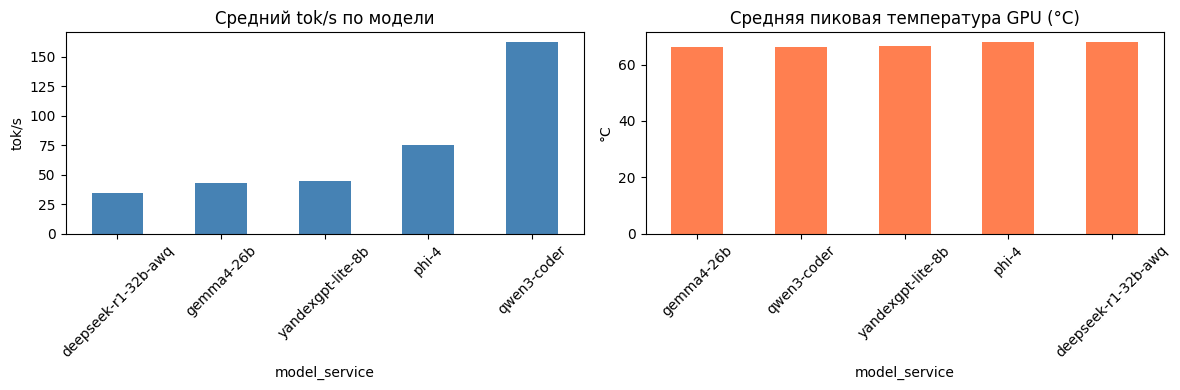

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt

if len(df) == 0:
    print("Нет данных для графиков.")
else:
    # Средняя скорость генерации (по completion_tokens и latency из ответа API).
    agg = df.groupby("model_service")["tok_per_sec"].mean().sort_values()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    agg.plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title("Средний tok/s по модели")
    axes[0].set_ylabel("tok/s")
    axes[0].tick_params(axis="x", rotation=45)

    # Средняя пиковая температура за все опросы модели.
    agg2 = df.groupby("model_service")["gpu_temp_c"].mean().sort_values()
    agg2.plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_title("Средняя пиковая температура GPU (°C)")
    axes[1].set_ylabel("°C")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Заключение

**Артефакт и последующая оценка качества.** Полученный в ходе выполнения блокнота файл **`benchmark_results.csv`** (табличное представление прогона) является основным продуктом данного этапа эксперимента. Его содержимое — тексты ответов моделей и измеренные показатели генерации и телеметрии — используется далее для **оценки качества генерации LLM-арбитрами** (три независимые модели-оценщика; постановка, шкалы и агрегирование оценок описаны в [analysis.md](analysis.md)).

**Универсальность цикла сбора данных.** Реализованный в настоящем блокноте цикл универсален для любых больших языковых моделей, которые по техническим характеристикам (объём VRAM, поддержка движком vLLM, доступность весов или контейнера) допускаются в выбранной среде развёртывания. Перенос на иной набор моделей сводится к корректировке списка сервисов, портов и строковых идентификаторов в конфигурации и, при необходимости, параметров `docker compose` на вычислительном узле при сохранении того же протокола запросов и записи наблюдений.